# Projeto Jaré — Análise Exploratória de Leads (EDA)

Análise exploratória da **camada curada** (`leads_clean`) do pipeline de leads
imobiliários, mais a camada de **desfecho simulado** (`lead_outcomes_demo`).

> ⚠️ **Dados sintéticos (demo).** Os atributos passam pelo pipeline real
> (ingestão → normalização → enriquecimento → dedup → *lead scoring*); o desfecho
> comercial (funil, ganho/perdido, tempo de resposta) é **simulado** — ver
> `src/seed.py`. Reproduza com `python -m src.seed`.

**Roteiro:** qualidade dos dados · origem e geografia · validação da rubrica de
*lead scoring* · funil de conversão · efeito do **tempo de resposta** · **padrões
temporais** de chegada dos leads.

In [1]:
import os
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 4)

# Localiza a raiz do repo e o banco demo; gera os dados se faltarem (notebook
# autocontido — roda de qualquer lugar, inclusive num clone novo).
ROOT = Path.cwd()
REPO = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(REPO))
DB = REPO / "data" / "demo.duckdb"
if not DB.exists():
    os.environ["DUCKDB_PATH"] = str(DB)
    from src.seed import run
    run(db_path=str(DB))
    from src import db
    db.close()

con = duckdb.connect(str(DB), read_only=True)
leads = con.execute("SELECT * FROM leads_clean").df()
outcomes = con.execute("SELECT * FROM lead_outcomes_demo").df()
con.close()

ORDER = ["Quente", "Morno", "Frio"]
CORES = {"Quente": "#ef4444", "Morno": "#f59e0b", "Frio": "#38bdf8"}
print(f"leads_clean........: {leads.shape[0]} linhas x {leads.shape[1]} colunas")
print(f"lead_outcomes_demo.: {outcomes.shape[0]} pessoas")
leads.head(3)

leads_clean........: 600 linhas x 31 colunas
lead_outcomes_demo.: 519 pessoas


,source,external_id,name,name_clean,email_clean,email_valid,email_domain,phone_e164,phone_ddd,phone_is_mobile,...,lead_date,received_at,person_key,is_primary,is_duplicate,cross_portal,listing_intent,lead_score,lead_temperature,trello_card_id
0,dfimoveis,dfimoveis-202602-00537-4876,Lorenzo Pereira,Lorenzo Pereira,davi-luccacardoso@example.com,True,example.com,+5565924455022,65,True,...,2026-02-04 14:39:52.796046-03:00,2026-02-04 14:39:52.796046-03:00,tel:+5565924455022,True,False,True,True,100,Quente,<NA>
1,dfimoveis,dfimoveis-202602-00338-9556,Lívia Sousa,Lívia Sousa,moraesemanuella@example.org,True,example.org,NaN,NaN,False,...,2026-02-04 17:23:52.796046-03:00,2026-02-04 17:23:52.796046-03:00,email:moraesemanuella@example.org,True,False,False,False,10,Frio,<NA>
2,dfimoveis,dfimoveis-202602-00095-4920,Calebe Aragão,Calebe Aragão,hadassa96@example.org,True,example.org,+5561941574733,61,True,...,2026-02-04 18:25:52.796046-03:00,2026-02-04 18:25:52.796046-03:00,tel:+5561941574733,True,False,False,True,100,Quente,<NA>


## 1. Visão geral

`leads_clean` tem uma linha por lead recebido; o dedup de identidade marca
`is_primary` (a pessoa) e `is_duplicate` (reentradas, inclusive entre portais).

In [2]:
pessoas = leads[leads["is_primary"]]
dup = int(leads["is_duplicate"].sum())
cross = int((leads["cross_portal"] & leads["is_duplicate"]).sum())
print(f"Leads recebidos....: {len(leads)}")
print(f"Pessoas únicas.....: {len(pessoas)}")
print(f"Duplicados.........: {dup} ({cross} cross-portal)")
print(f"Período............: {leads['received_at'].min():%d/%m/%Y} a {leads['received_at'].max():%d/%m/%Y}")

Leads recebidos....: 600
Pessoas únicas.....: 526
Duplicados.........: 74 (46 cross-portal)
Período............: 04/02/2026 a 04/06/2026


## 2. Qualidade dos dados

O transform valida telefone (DDD contra a tabela da Anatel) e e-mail. Dado inválido
não contamina o *lead scoring* nem a chave de dedup de identidade.

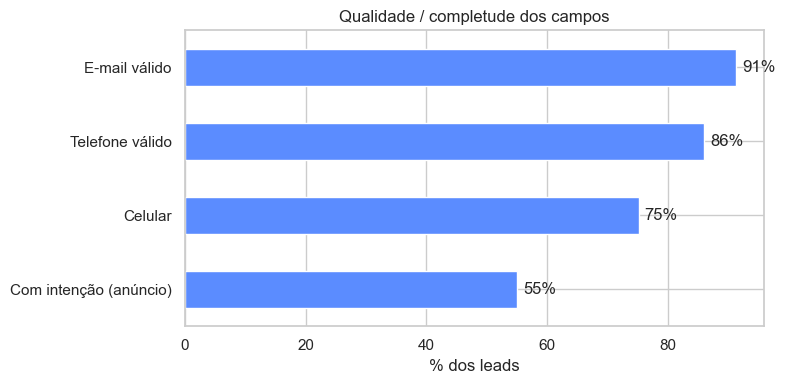

In [3]:
qual = pd.Series({
    "Telefone válido": leads["phone_valid"].mean(),
    "Celular": leads["phone_is_mobile"].mean(),
    "E-mail válido": leads["email_valid"].mean(),
    "Com intenção (anúncio)": leads["listing_intent"].mean(),
}) * 100
ax = qual.sort_values().plot.barh(color="#5b8cff")
ax.set_xlabel("% dos leads")
ax.set_title("Qualidade / completude dos campos")
for i, v in enumerate(qual.sort_values()):
    ax.text(v + 1, i, f"{v:.0f}%", va="center")
plt.tight_layout()
plt.show()

## 3. Origem e geografia

Dois portais alimentam o funil. A geografia vem do DDD do telefone (DDD → UF →
região); como a corretora é de Brasília, o **DF domina** — por isso no dashboard a
geografia é um indicador compacto, não o foco da análise.

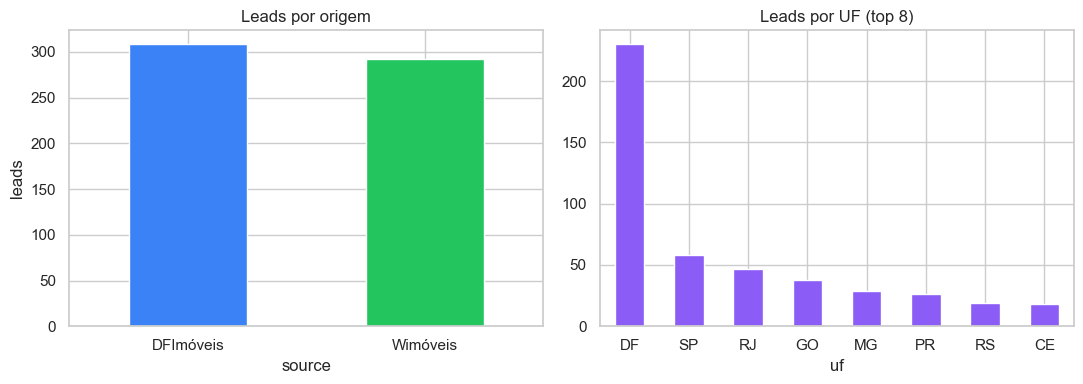

43% dos leads com DDD identificado são do DF.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
src_lbl = leads["source"].map({"wimoveis": "Wimóveis", "dfimoveis": "DFImóveis"})
src_lbl.value_counts().plot.bar(ax=axes[0], color=["#3b82f6", "#22c55e"])
axes[0].set_title("Leads por origem")
axes[0].set_ylabel("leads")
axes[0].tick_params(axis="x", rotation=0)
leads["uf"].value_counts().head(8).plot.bar(ax=axes[1], color="#8b5cf6")
axes[1].set_title("Leads por UF (top 8)")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
pct_df = 100 * (leads["uf"] == "DF").sum() / leads["uf"].notna().sum()
print(f"{pct_df:.0f}% dos leads com DDD identificado são do DF.")

## 4. Lead scoring — a rubrica se sustenta?

Rubrica do cliente: **intenção num anúncio (60) > telefone (25, +5 celular) >
e-mail (10)**. O piso da intenção (60) é maior que a soma do resto (40), então
*qualquer* lead com intenção deve pontuar acima de *qualquer* lead sem ela.
Validamos empiricamente.

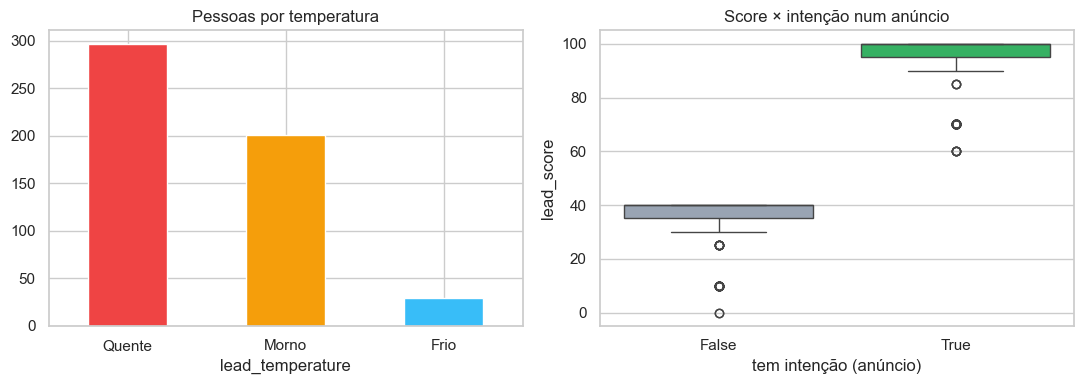

Menor score COM intenção: 60  |  Maior score SEM intenção: 40
Hierarquia respeitada ✅


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pessoas["lead_temperature"].value_counts().reindex(ORDER).plot.bar(
    ax=axes[0], color=[CORES[t] for t in ORDER]
)
axes[0].set_title("Pessoas por temperatura")
axes[0].tick_params(axis="x", rotation=0)
sns.boxplot(
    data=pessoas, x="listing_intent", y="lead_score", ax=axes[1],
    hue="listing_intent", palette=["#94a3b8", "#22c55e"], legend=False,
)
axes[1].set_title("Score × intenção num anúncio")
axes[1].set_xlabel("tem intenção (anúncio)")
plt.tight_layout()
plt.show()

com = pessoas[pessoas["listing_intent"]]["lead_score"].min()
sem = pessoas[~pessoas["listing_intent"]]["lead_score"].max()
print(f"Menor score COM intenção: {com}  |  Maior score SEM intenção: {sem}")
print("Hierarquia respeitada ✅" if com > sem else "Hierarquia QUEBRADA ❌")

## 5. Desfecho (demo): funil de conversão

Funil das pessoas únicas pelos estágios (Novos → Em contato → Visita → Proposta →
Fechado). A win-rate por temperatura deve crescer com o calor do lead.

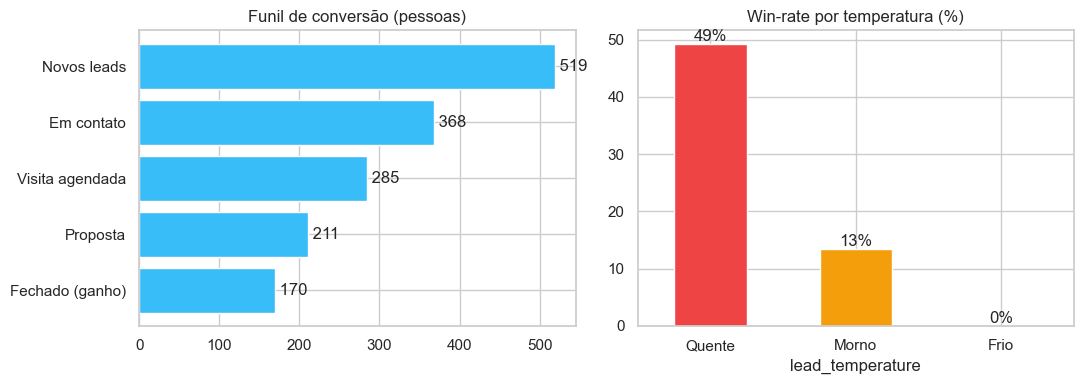

In [6]:
stages = ["Novos leads", "Em contato", "Visita agendada", "Proposta", "Fechado (ganho)"]
counts = [int((outcomes["stage_index"] >= i).sum()) for i in range(len(stages))]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].barh(stages[::-1], counts[::-1], color="#38bdf8")
axes[0].set_title("Funil de conversão (pessoas)")
for i, v in enumerate(counts[::-1]):
    axes[0].text(v, i, f" {v}", va="center")
wr = (
    outcomes.assign(won=outcomes["status"].eq("won"))
    .groupby("lead_temperature")["won"].mean().mul(100).reindex(ORDER)
)
wr.plot.bar(ax=axes[1], color=[CORES[t] for t in ORDER])
axes[1].set_title("Win-rate por temperatura (%)")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(wr):
    axes[1].text(i, v, f"{v:.0f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 6. Tempo de resposta × conversão

Hipótese de negócio: **responder rápido converte mais.** Comparamos a win-rate de
quem foi respondido dentro do SLA (≤ 60 min) com o restante.

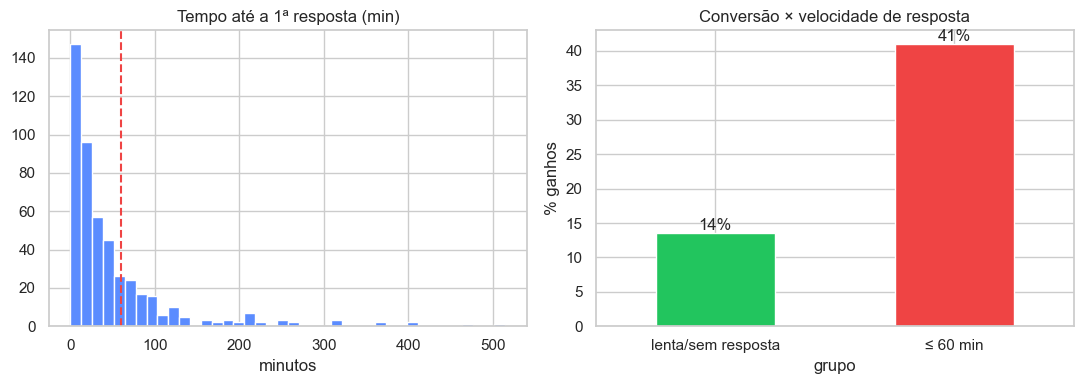

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
resp = outcomes["first_response_minutes"].dropna()
axes[0].hist(resp, bins=40, color="#5b8cff")
axes[0].axvline(60, color="#ef4444", ls="--")
axes[0].set_title("Tempo até a 1ª resposta (min)")
axes[0].set_xlabel("minutos")
sla = outcomes.assign(
    won=outcomes["status"].eq("won"),
    grupo=outcomes["responded_within_sla"].map({True: "≤ 60 min", False: "lenta/sem resposta"}),
)
g = sla.groupby("grupo")["won"].mean().mul(100)
g.plot.bar(ax=axes[1], color=["#22c55e", "#ef4444"])
axes[1].set_title("Conversão × velocidade de resposta")
axes[1].set_ylabel("% ganhos")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(g):
    axes[1].text(i, v, f"{v:.0f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 7. Quando os leads chegam

Dia da semana e hora (horário de Brasília) — insumo para dimensionar o **plantão de
resposta** e melhorar o SLA.

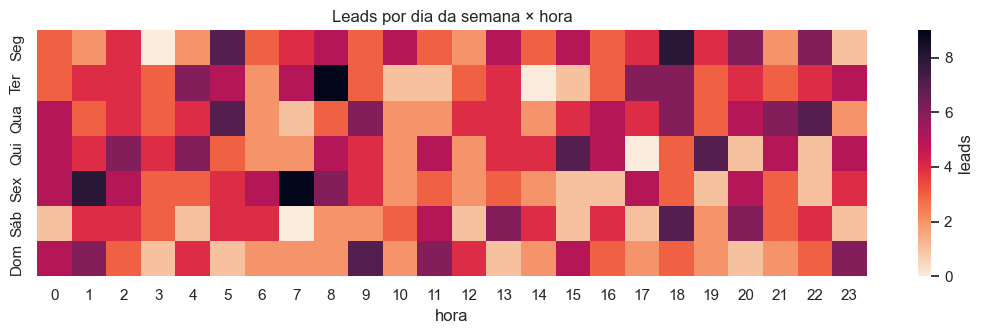

In [8]:
local = pd.to_datetime(leads["received_at"], utc=True).dt.tz_convert("America/Sao_Paulo")
tmp = leads.assign(dow=local.dt.dayofweek, hora=local.dt.hour)
piv = tmp.pivot_table(index="dow", columns="hora", values="external_id", aggfunc="count", fill_value=0)
piv = piv.reindex(range(7))
piv.index = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
plt.figure(figsize=(11, 3.5))
sns.heatmap(piv, cmap="rocket_r", cbar_kws={"label": "leads"})
plt.title("Leads por dia da semana × hora")
plt.xlabel("hora")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Conclusões

- **Qualidade:** a validação de telefone/e-mail filtra dado lixo antes do scoring e
  do dedup — só telefone BR válido vira chave de identidade.
- **Dedup de identidade:** parte dos leads são reentradas da mesma pessoa (inclusive
  *cross-portal*) — sem o dedup, virariam cards e contagens duplicados.
- **Lead scoring:** a hierarquia da rubrica do cliente se sustenta nos dados — todo
  lead com intenção num anúncio pontua acima de todo lead sem ela.
- **Conversão:** cresce com a temperatura — o scoring prioriza quem tem mais chance
  de fechar.
- **Tempo de resposta:** responder dentro do SLA está associado a maior conversão —
  justifica um alerta de SLA e organizar o plantão pelos horários de pico.

*Correlações de desfecho refletem o modelo de simulação (`src/seed.py`); com a
captura real do desfecho do Trello, a mesma análise roda sobre dados reais.*